In [ ]:
from huggingface_hub import login
import pandas as pd

login(token="********************")
splits = {'vinmec_article_subtitle': 'data/vinmec_article_subtitle-00000-of-00001-e98cf5ea3053f42f.parquet', 'medical_qa': 'data/medical_qa-00000-of-00001-5ff72792fc000f50.parquet', 'full': 'data/full-00000-of-00001-5cf852564dfb41df.parquet', 'vinmec_article_content': 'data/vinmec_article_content-00000-of-00001-d24ac05490384885.parquet', 'vinmec_article_main': 'data/vinmec_article_main-00000-of-00001-fb76eca8bdfcf377.parquet'}
base_url = "hf://datasets/urnus11/Vietnamese-Healthcare/"

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import re

In [ ]:
print("📥 Đang tải tất cả các phần của dataset...\n")
datasets = {}

for name, path in splits.items():
    datasets[name] = pd.read_parquet(base_url + path)

print(f"\n🎉 Hoàn thành! Đã tải {len(datasets)} phần của dataset")

📥 Đang tải tất cả các phần của dataset...



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



🎉 Hoàn thành! Đã tải 5 phần của dataset


In [ ]:
%%capture
!pip install rank-bm25

In [ ]:
from tqdm import tqdm
from rank_bm25 import BM25Okapi
import re
from collections import defaultdict
import pickle

tqdm.pandas()
pd.set_option('display.max_colwidth', 200)

In [ ]:
def preprocess_text(text):
    """
    Tiền xử lý text tiếng Việt
    """
    if pd.isna(text) or text == "":
        return ""

    # Chuyển về lowercase
    text = str(text).lower()

    # Loại bỏ HTML tags nếu có
    text = re.sub(r'<[^>]+>', ' ', text)

    # Loại bỏ URLs
    text = re.sub(r'http\S+|www.\S+', ' ', text)

    # Loại bỏ các ký tự đặc biệt, giữ lại chữ cái tiếng Việt
    text = re.sub(r'[^\w\s\u00C0-\u1EF9]', ' ', text)

    # Loại bỏ khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def tokenize_vietnamese(text):
    """
    Tokenize đơn giản cho tiếng Việt (word-level)
    """
    return preprocess_text(text).split()

In [ ]:
print("📚 Đang chuẩn bị corpus từ vinmec_article_subtitle...\n")

# Lấy dữ liệu
article_subtitle = datasets['vinmec_article_subtitle'].copy()

# Thêm ID cho mỗi passage
article_subtitle['passage_id'] = [f"passage_{i}" for i in range(len(article_subtitle))]

# Tiền xử lý content
article_subtitle['content_processed'] = article_subtitle['content'].progress_apply(preprocess_text)

# Loại bỏ các passages rỗng hoặc quá ngắn
article_subtitle = article_subtitle[
    (article_subtitle['content_processed'].str.len() > 20)
].reset_index(drop=True)

print(f"✅ Corpus gồm {len(article_subtitle)} passages")
print(f"📊 Độ dài trung bình: {article_subtitle['content'].str.len().mean():.0f} ký tự")
print(f"📊 Độ dài trung bình sau xử lý: {article_subtitle['content_processed'].str.len().mean():.0f} ký tự")

# Hiển thị mẫu
print("\n📝 Mẫu passage:")
print(article_subtitle[['passage_id', 'title', 'content']].head(2))

📚 Đang chuẩn bị corpus từ vinmec_article_subtitle...



100%|██████████| 163186/163186 [00:26<00:00, 6215.91it/s]


✅ Corpus gồm 163181 passages
📊 Độ dài trung bình: 1104 ký tự
📊 Độ dài trung bình sau xử lý: 1075 ký tự

📝 Mẫu passage:
   passage_id                                         title  \
0           0  Mục đích của kỹ thuật mở màng phổi tối thiểu   
1           1                Chỉ định mở màng phổi khi nào?   

                                                                                               content  
0  1. Mục đích của kỹ thuật mở màng phổi tối thiểu\nPhục hồi lại áp lực âm trong khoang màng phổi g...  
1  2. Chỉ định mở màng phổi khi nào?\nMở màng phổi tối thiểu đặt ống thông vào lồng ngực có thể đượ...  


In [ ]:
print("🔨 Đang xây dựng BM25 index...\n")

# Tokenize toàn bộ corpus
print("⏳ Đang tokenize corpus...")
tokenized_corpus = article_subtitle['content_processed'].progress_apply(
    lambda x: x.split()
).tolist()

# Khởi tạo BM25
print("⏳ Đang khởi tạo BM25...")
bm25 = BM25Okapi(tokenized_corpus)

print("✅ Đã xây dựng xong BM25 index!")

# Lưu lại để sử dụng sau (optional)
# with open('bm25_index.pkl', 'wb') as f:
#     pickle.dump(bm25, f)

🔨 Đang xây dựng BM25 index...

⏳ Đang tokenize corpus...


100%|██████████| 163181/163181 [00:05<00:00, 28119.26it/s]


⏳ Đang khởi tạo BM25...
✅ Đã xây dựng xong BM25 index!


In [ ]:
def retrieve_contexts_bm25(question, bm25_model, corpus_df, top_k=5):
    """
    Retrieve top-k contexts phù hợp nhất cho câu hỏi

    Args:
        question: Câu hỏi cần tìm context
        bm25_model: Model BM25 đã train
        corpus_df: DataFrame chứa corpus
        top_k: Số lượng contexts cần lấy

    Returns:
        DataFrame chứa top-k contexts với scores
    """
    # Tokenize câu hỏi
    tokenized_query = tokenize_vietnamese(question)

    # Lấy scores cho tất cả documents
    scores = bm25_model.get_scores(tokenized_query)

    # Lấy top-k indices
    top_indices = np.argsort(scores)[-top_k:][::-1]
    top_scores = scores[top_indices]

    # Lấy contexts tương ứng
    retrieved_contexts = corpus_df.iloc[top_indices].copy()
    retrieved_contexts['bm25_score'] = top_scores
    retrieved_contexts['rank'] = range(1, top_k + 1)

    return retrieved_contexts[['passage_id', 'title', 'content', 'url', 'bm25_score', 'rank']]

# Test với một câu hỏi
test_question = datasets['medical_qa'].iloc[1]['title']
print(f"🔍 Test với câu hỏi: {test_question}\n")

test_results = retrieve_contexts_bm25(test_question, bm25, article_subtitle, top_k=1)
print("📋 Top 1 context:")
test_results[['rank', 'bm25_score', 'content']].to_string()

🔍 Test với câu hỏi: Đau đầu, căng thẳng do công việc, suy giảm trí nhớ khoảng gần một năm phải làm sao?

📋 Top 1 context:


'       rank  bm25_score                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      content\n43718     1   31.347931  2. Nguyên nhân suy giảm trí nhớ ở người trẻ là do đâu?\\n2.4. Suy giảm trí nhớ ở người trẻ do trầm cảm và stress Một trong những nguyên gây suy giảm trí nhớ mất tập trung thường gặp liên quan đến vấn đề tâm lý căng thẳng. Hiện nay, người trẻ gặp phải rất nhiều khó khăn trong cuộc sống đến từ công việc, học hành

In [ ]:
print("🔄 Đang retrieve contexts cho toàn bộ medical_qa dataset...\n")

medical_qa = datasets['medical_qa'].copy()

# Số lượng contexts cần lấy cho mỗi câu hỏi
TOP_K_CONTEXTS = 3

# Lưu kết quả
all_kb_records = []

for idx, qa_row in tqdm(medical_qa.iterrows(), total=len(medical_qa), desc="Processing QA pairs"):
    question = qa_row['title']
    answer = qa_row['content']
    qa_url = qa_row.get('url', '')

    # Retrieve contexts
    retrieved = retrieve_contexts_bm25(
        question=question,
        bm25_model=bm25,
        corpus_df=article_subtitle,
        top_k=TOP_K_CONTEXTS
    )

    # Tạo record cho KB
    contexts_list = []
    for _, ctx in retrieved.iterrows():
        contexts_list.append({
            'passage_id': ctx['passage_id'],
            'text': ctx['content'],
            'title': ctx['title'],
            'source_url': ctx['url'],
            'bm25_score': float(ctx['bm25_score']),
            'rank': int(ctx['rank'])
        })

    kb_record = {
        'qa_id': f"qa_{idx}",
        'question': question,
        'answer': answer,
        'qa_source_url': qa_url,
        'contexts': contexts_list,
        'num_contexts': len(contexts_list),
        'top_context_score': contexts_list[0]['bm25_score'] if contexts_list else 0
    }

    all_kb_records.append(kb_record)

print(f"\n✅ Hoàn thành! Đã tạo {len(all_kb_records)} KB records")

🔄 Đang retrieve contexts cho toàn bộ medical_qa dataset...



Processing QA pairs:   0%|          | 4/10015 [00:14<10:00:54,  3.60s/it]


KeyboardInterrupt: 

In [ ]:
# Tạo DataFrame "flat" để dễ phân tích
kb_flat_records = []

for kb_record in all_kb_records:
    for ctx in kb_record['contexts']:
        flat_record = {
            'qa_id': kb_record['qa_id'],
            'question': kb_record['question'],
            'answer': kb_record['answer'],
            'context_text': ctx['text'],
            'context_title': ctx['title'],
            'context_source_url': ctx['source_url'],
            'bm25_score': ctx['bm25_score'],
            'rank': ctx['rank']
        }
        kb_flat_records.append(flat_record)

kb_flat_df = pd.DataFrame(kb_flat_records)

print(f"📊 Knowledge Base (flat format): {len(kb_flat_df)} records")
print(f"📊 Unique QA pairs: {kb_flat_df['qa_id'].nunique()}")
print(f"📊 Unique contexts: {kb_flat_df['context_text'].nunique()}")

# Hiển thị mẫu
print("\n📝 Mẫu KB record:")
print(kb_flat_df[['qa_id', 'question', 'context_title', 'bm25_score', 'rank']].head(10))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Phân tích score distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribution của BM25 scores
axes[0, 0].hist(kb_flat_df['bm25_score'], bins=50, edgecolor='black')
axes[0, 0].set_title('Phân phối BM25 Scores', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('BM25 Score')
axes[0, 0].set_ylabel('Tần suất')
axes[0, 0].grid(alpha=0.3)

# 2. Score theo rank
rank_scores = kb_flat_df.groupby('rank')['bm25_score'].agg(['mean', 'std']).reset_index()
axes[0, 1].bar(rank_scores['rank'], rank_scores['mean'], yerr=rank_scores['std'],
               capsize=5, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 1].set_title('BM25 Score trung bình theo Rank', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Rank')
axes[0, 1].set_ylabel('Mean BM25 Score')
axes[0, 1].grid(alpha=0.3)

# 3. Top contexts được retrieve nhiều nhất
top_contexts = kb_flat_df['context_title'].value_counts().head(10)
axes[1, 0].barh(range(len(top_contexts)), top_contexts.values, color='coral', edgecolor='black')
axes[1, 0].set_yticks(range(len(top_contexts)))
axes[1, 0].set_yticklabels([title[:40] + '...' if len(title) > 40 else title
                             for title in top_contexts.index], fontsize=9)
axes[1, 0].set_title('Top 10 contexts được retrieve nhiều nhất', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Số lần xuất hiện')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(alpha=0.3, axis='x')

# 4. Độ dài context vs BM25 score
context_lengths = kb_flat_df['context_text'].str.len()
axes[1, 1].scatter(context_lengths, kb_flat_df['bm25_score'], alpha=0.3, s=10)
axes[1, 1].set_title('Mối quan hệ giữa độ dài context và BM25 score', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Độ dài context (ký tự)')
axes[1, 1].set_ylabel('BM25 Score')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("\n📈 THỐNG KÊ RETRIEVAL:")
print(f"   • BM25 Score trung bình: {kb_flat_df['bm25_score'].mean():.2f}")
print(f"   • BM25 Score median: {kb_flat_df['bm25_score'].median():.2f}")
print(f"   • BM25 Score std: {kb_flat_df['bm25_score'].std():.2f}")
print(f"   • Số contexts unique được sử dụng: {kb_flat_df['context_text'].nunique()}")
print(f"   • Coverage: {kb_flat_df['context_text'].nunique() / len(article_subtitle) * 100:.1f}%")

In [ ]:
# Sample một số QA pairs và xem contexts được retrieve
def show_qa_with_contexts(kb_records, idx=0):
    """
    Hiển thị một QA pair với contexts được retrieve
    """
    record = kb_records[idx]

    print("="*100)
    print(f"QA ID: {record['qa_id']}")
    print(f"\n❓ CÂU HỎI:\n{record['question']}")
    print(f"\n✅ CÂU TRẢ LỜI:\n{record['answer'][:300]}..." if len(record['answer']) > 300 else f"\n✅ CÂU TRẢ LỜI:\n{record['answer']}")
    print(f"\n📚 CONTEXTS (Top {record['num_contexts']}):\n")

    for ctx in record['contexts']:
        print(f"  Rank {ctx['rank']} | Score: {ctx['bm25_score']:.2f}")
        print(f"  📌 Title: {ctx['title']}")
        print(f"  📝 Text: {ctx['text'][:200]}..." if len(ctx['text']) > 200 else f"  📝 Text: {ctx['text']}")
        print(f"  🔗 Source: {ctx['source_url']}")
        print("-" * 100)

# Hiển thị 3 ví dụ random
print("🎲 SAMPLING 3 QA PAIRS NGẪU NHIÊN:\n")
random_indices = np.random.choice(len(all_kb_records), size=min(3, len(all_kb_records)), replace=False)

for i, idx in enumerate(random_indices):
    show_qa_with_contexts(all_kb_records, idx)
    if i < len(random_indices) - 1:
        print("\n" * 2)

In [ ]:
import json

# Lưu dạng JSON (format đầy đủ với nested contexts)
output_json = '/kaggle/working/knowledge_base.json'
with open(output_json, 'w', encoding='utf-8') as f:
    json.dump(all_kb_records, f, ensure_ascii=False, indent=2)

print(f"✅ Đã lưu Knowledge Base (JSON format) vào: {output_json}")

# Lưu dạng CSV (flat format)
output_csv = 'knowledge_base_flat.csv'
kb_flat_df.to_csv(output_csv, index=False, encoding='utf-8-sig')
print(f"✅ Đã lưu Knowledge Base (CSV format) vào: {output_csv}")

# Lưu dạng Parquet (nén tốt hơn)
output_parquet = 'knowledge_base_flat.parquet'
kb_flat_df.to_parquet(output_parquet, index=False)
print(f"✅ Đã lưu Knowledge Base (Parquet format) vào: {output_parquet}")

# Summary
print(f"\n📊 TỔNG KẾT:")
print(f"   • Tổng số QA pairs: {len(all_kb_records)}")
print(f"   • Contexts per QA: {TOP_K_CONTEXTS}")
print(f"   • Tổng số records (flat): {len(kb_flat_df)}")
print(f"   • File sizes:")
print(f"     - JSON: {os.path.getsize(output_json) / 1024 / 1024:.2f} MB")
print(f"     - CSV: {os.path.getsize(output_csv) / 1024 / 1024:.2f} MB")
print(f"     - Parquet: {os.path.getsize(output_parquet) / 1024 / 1024:.2f} MB")

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
with open('/content/drive/MyDrive/DO_AN_DS_KI_1_NAM_3/DS201/Nvu/knowledge_base/kb_data/knowledge_base.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

In [5]:
import pandas as pd

bm25_rank_data = []

for record in data:
    if 'contexts' in record and isinstance(record['contexts'], list):
        for context in record['contexts']:
            bm25_score = context.get('bm25_score')
            rank = context.get('rank')
            if bm25_score is not None and rank is not None:
                bm25_rank_data.append({'bm25_score': bm25_score, 'rank': rank})

bm25_rank_df = pd.DataFrame(bm25_rank_data)

print(f"Đã trích xuất {len(bm25_rank_df)} cặp BM25 score và rank.")
print("5 hàng đầu tiên của DataFrame bm25_rank_df:")
print(bm25_rank_df.head())

Đã trích xuất 30045 cặp BM25 score và rank.
5 hàng đầu tiên của DataFrame bm25_rank_df:
   bm25_score  rank
0   53.390451     1
1   44.772497     2
2   44.357717     3
3   31.347931     1
4   30.368115     2


In [9]:
rank_stats = bm25_rank_df.groupby('rank')['bm25_score'].agg(['min', 'max','mean', 'std']).reset_index()

print("Thống kê BM25 Score trung bình và độ lệch chuẩn theo Rank:")
print(rank_stats)


Thống kê BM25 Score trung bình và độ lệch chuẩn theo Rank:
   rank        min         max       mean        std
0     1  11.833003  501.551864  58.011221  41.339028
1     2  10.949921  489.943267  55.647232  39.960101
2     3  10.677919  486.426774  54.243747  39.151702


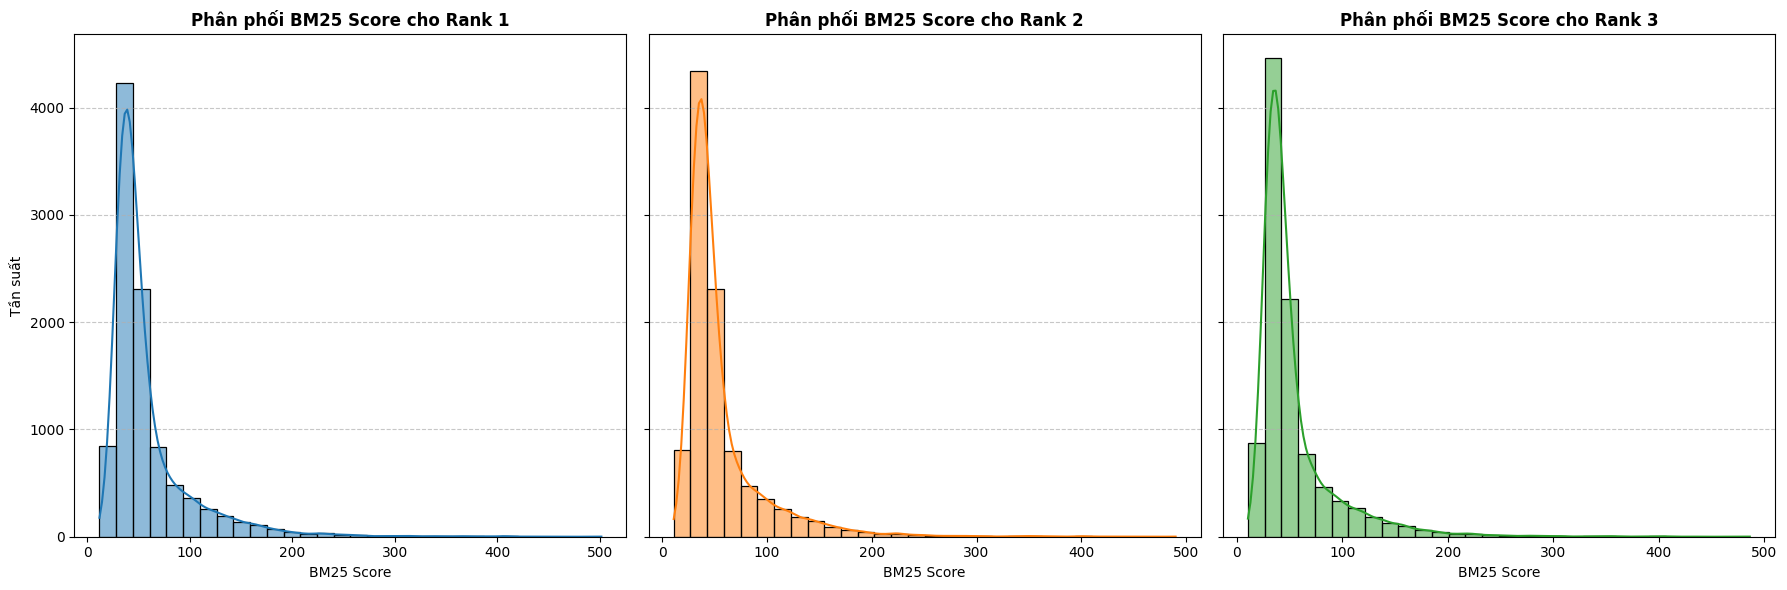

Đã hiển thị biểu đồ histogram phân phối BM25 Score cho từng Rank.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_ranks = bm25_rank_df['rank'].unique()
unique_ranks.sort() # Sắp xếp các rank để hiển thị thứ tự

# Xác định số lượng subplot cần thiết
num_plots = len(unique_ranks)
fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6), sharey=True)

# Đảm bảo axes là một mảng nếu chỉ có một subplot
if num_plots == 1:
    axes = [axes]

for i, rank_val in enumerate(unique_ranks):
    subset = bm25_rank_df[bm25_rank_df['rank'] == rank_val]

    sns.histplot(subset['bm25_score'], bins=30, kde=True, ax=axes[i], color=f'C{i}', edgecolor='black')

    axes[i].set_title(f'Phân phối BM25 Score cho Rank {rank_val}', fontsize=12, weight='bold')
    axes[i].set_xlabel('BM25 Score', fontsize=10)
    if i == 0: # Chỉ đặt nhãn y cho subplot đầu tiên để tránh trùng lặp
        axes[i].set_ylabel('Tần suất', fontsize=10)
    else:
        axes[i].set_ylabel('') # Xóa nhãn y cho các subplot còn lại
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Đã hiển thị biểu đồ histogram phân phối BM25 Score cho từng Rank.")

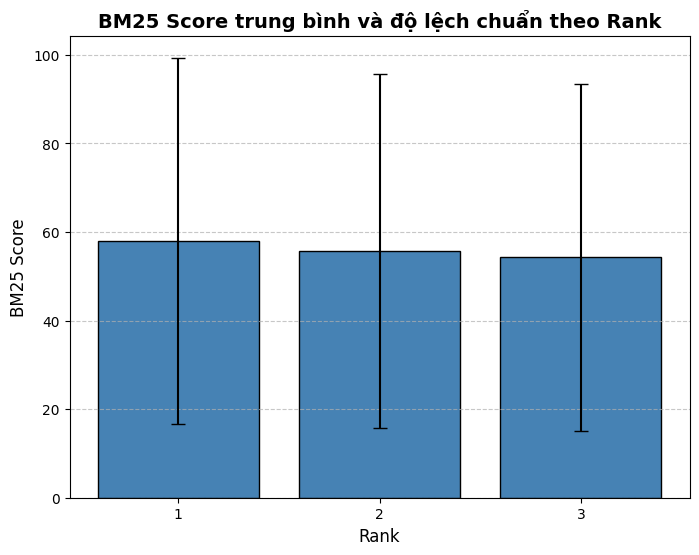

Đã hiển thị biểu đồ phân phối BM25 Score theo Rank.


In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Use plt.bar directly as data is already aggregated
plt.bar(x=rank_stats['rank'], height=rank_stats['mean'], yerr=rank_stats['std'],
        capsize=5, color='steelblue', edgecolor='black')

plt.title('BM25 Score trung bình và độ lệch chuẩn theo Rank', fontsize=14, weight='bold')
plt.xlabel('Rank', fontsize=12)
plt.ylabel('BM25 Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rank_stats['rank']) # Ensure x-axis ticks are at the rank values
plt.show()

print("Đã hiển thị biểu đồ phân phối BM25 Score theo Rank.")